In [1]:
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta, datetime
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def add_relative_direction_features(df):
    df['relative_wave_direction'] = (df['wave_direction'] - df['course']) % 360
    df['relative_wind_wave_direction'] = (df['wind_wave_direction'] - df['course']) % 360
    df['relative_swell_wave_direction'] = (df['swell_wave_direction'] - df['course']) % 360
    df['relative_wind_direction_10m'] = (df['wind_direction_10m'] - df['course'] + 360) % 360
    df['relative_ocean_current_direction'] = (df['ocean_current_direction'] - df['course'] + 360) % 360

    rel_angle_rad_wind_wave = np.deg2rad(df['relative_wind_wave_direction'])
    rel_angle_rad_swell_wave = np.deg2rad(df['relative_swell_wave_direction'])
    rel_angle_rad_current = np.deg2rad(df['relative_ocean_current_direction'])

    df['wind_wave_effect_forward'] = df['wind_wave_height'] * np.cos(rel_angle_rad_wind_wave)
    df['wind_wave_effect_side'] = df['wind_wave_height'] * np.sin(rel_angle_rad_wind_wave)

    df['swell_effect_forward'] = df['swell_wave_height'] * np.cos(rel_angle_rad_swell_wave)
    df['swell_effect_side'] = df['swell_wave_height'] * np.sin(rel_angle_rad_swell_wave)

    df['ocean_current_effect_forward'] = df['ocean_current_velocity'] * np.cos(rel_angle_rad_current)
    df['ocean_current_effect_side'] = df['ocean_current_velocity'] * np.sin(rel_angle_rad_current)

    df.drop(columns=['wave_direction', 'relative_wave_direction',
                     'wind_wave_direction', 'relative_wind_wave_direction',
                     'swell_wave_direction', 'relative_swell_wave_direction',
                     'wind_direction_10m', 'relative_wind_direction_10m',
                     'ocean_current_direction', 'relative_ocean_current_direction'], inplace=True)
    
    return df

/Users/itsgil/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
weather_df = pd.read_pickle("full_weather.pkl")
weather_df['date'] = pd.to_datetime(weather_df['date'])

hurdat_df = pd.read_pickle("hurdat2_storm_data_2020_2025.pkl")
hurdat_df['storm_timestamp'] = pd.to_datetime(hurdat_df['datetime'])

vessel_info = pd.read_csv("vessel_info.csv")

In [ ]:
deviation_records = []

COURSE_CHANGE_THRESHOLD = 5  # degrees
STORM_DISTANCE_NM = 800       # nautical miles
STORM_TIME_WINDOW_HOURS = 48  # hours before/after
MAX_LOOKBACK_HOURS = 24        # Look for course change within this timeframe

for journey_id, group in tqdm(weather_df.groupby('journey_id'), desc="Processing journeys"):
    group = group.sort_values('date').reset_index(drop=True)
    for idx, row in group.iterrows():
        ship_lat = row['lat']
        ship_lon = row['lon']
        ship_time = row['date']
        ship_course = row['course']
        mmsi = row['mmsi']
        # Look back for previous entry within MAX_LOOKBACK_HOURS
        lookback = group[(group['date'] < ship_time) & (group['date'] >= ship_time - pd.Timedelta(hours=MAX_LOOKBACK_HOURS))]
        if not lookback.empty:
            prev_row = lookback.iloc[-1]
            prev_course = prev_row['course']
            course_change = abs(ship_course - prev_course)
            if course_change > COURSE_CHANGE_THRESHOLD:
                # Find storms within +/- STORM_TIME_WINDOW_HOURS of ship_time
                storms_nearby = hurdat_df[
                    (hurdat_df['storm_timestamp'] >= ship_time - pd.Timedelta(hours=STORM_TIME_WINDOW_HOURS)) &
                    (hurdat_df['storm_timestamp'] <= ship_time + pd.Timedelta(hours=STORM_TIME_WINDOW_HOURS))
                ].copy()
                storms_nearby['distance_nm'] = storms_nearby.apply(
                    lambda x: haversine_nm(ship_lat, ship_lon, x['lat'], x['lon']), axis=1
                )
                storms_nearby = storms_nearby[storms_nearby['distance_nm'] <= STORM_DISTANCE_NM]
                if not storms_nearby.empty:
                    # Take the closest storm nearby
                    storm = storms_nearby.loc[storms_nearby['distance_nm'].astype(float).idxmin()]
                    # Add weather data for prev_row (prefix with prev_)
                    prev_weather = {f'prev_{col}': prev_row[col] for col in weather_df.columns if col not in ['journey_id', 'lat', 'lon', 'date', 'course', 'mmsi']}
                    # Calculate prev_storm_distance
                    prev_storm_distance = haversine_nm(prev_row['lat'], prev_row['lon'], storm['lat'], storm['lon'])
                    deviation_records.append({
                        'prev_time': prev_row['date'],
                        'prev_lat': prev_row['lat'],
                        'prev_lon': prev_row['lon'],
                        'prev_course': prev_course,
                        'date': ship_time,
                        'lat': ship_lat,
                        'lon': ship_lon,
                        'course': ship_course,
                        'course_change': course_change,
                        'destination_lat': row.get('destination_lat', None),
                        'destination_lon': row.get('destination_lon', None),
                        'storm_time': storm['storm_timestamp'],
                        'storm_lat': storm['lat'],
                        'storm_lon': storm['lon'],
                        'storm_distance_nm': storm['distance_nm'],
                        'prev_storm_distance': prev_storm_distance,
                        'storm_wind': storm['max_sustained_wind'],
                        'mmsi': mmsi,
                        **prev_weather,
                        **{col: row[col] for col in weather_df.columns if col not in ['journey_id', 'lat', 'lon', 'date', 'course', 'mmsi']}
                    })

deviation_df = pd.DataFrame(deviation_records)

# Merge vessel info
deviation_df = deviation_df.merge(
    vessel_info[['mmsi', 'speed_max']],
    on='mmsi',
    how='left'
)

# Drop journey_id and mmsi
deviation_df = deviation_df.drop(columns=['journey_id', 'mmsi', 'course_change', 'prev_destination', 'prev_shipid', 'prev_speed_kn', 'prev_source', 'prev_nav_status', 'prev_draught', 'shipid', 'speed_kn', 'source', 'nav_status', 'draught', 'destination'], errors='ignore')

deviation_df.to_csv("course_deviation_storms.csv", index=False)
deviation_df

In [ ]:
# Transform each deviation into two entries (start and end) with unified column names

deviation_df = deviation_df.reset_index(drop=True)
deviation_df['deviation_id'] = deviation_df.index

# Start (prev) entry: use prev_* columns, prev_storm_distance as storm_distance_nm
start_map = {
    'prev_time': 'time',
    'prev_lat': 'lat',
    'prev_lon': 'lon',
    'prev_course': 'course',
    'prev_destination_lat': 'destination_lat',
    'prev_destination_lon': 'destination_lon',
    'prev_wave_height': 'wave_height',
    'prev_wave_direction': 'wave_direction',
    'prev_wave_period': 'wave_period',
    'prev_wind_wave_height': 'wind_wave_height',
    'prev_wind_wave_direction': 'wind_wave_direction',
    'prev_wind_wave_period': 'wind_wave_period',
    'prev_swell_wave_height': 'swell_wave_height',
    'prev_swell_wave_direction': 'swell_wave_direction',
    'prev_swell_wave_period': 'swell_wave_period',
    'prev_ocean_current_velocity': 'ocean_current_velocity',
    'prev_ocean_current_direction': 'ocean_current_direction',
    'prev_wind_speed_10m': 'wind_speed_10m',
    'prev_wind_direction_10m': 'wind_direction_10m',
    'prev_storm_distance': 'storm_distance_nm'
}

start_cols = list(start_map.keys()) + [
    'storm_time', 'storm_lat', 'storm_lon', 'storm_wind',
    'speed_max', 'deviation_id'
]
end_cols = [
    'date', 'lat', 'lon', 'course', 'destination_lat', 'destination_lon',
    'wave_height', 'wave_direction', 'wave_period',
    'wind_wave_height', 'wind_wave_direction', 'wind_wave_period',
    'swell_wave_height', 'swell_wave_direction', 'swell_wave_period',
    'ocean_current_velocity', 'ocean_current_direction',
    'wind_speed_10m', 'wind_direction_10m',
    'storm_time', 'storm_lat', 'storm_lon', 'storm_distance_nm', 'storm_wind',
    'speed_max', 'deviation_id'
]

# Build start entries
start_entries = deviation_df[start_cols].copy()
start_entries = start_entries.rename(columns=start_map)
start_entries['entry_type'] = 'start'

# Build end entries
end_entries = deviation_df[end_cols].copy()
end_entries = end_entries.rename(columns={'date': 'time'})
end_entries['entry_type'] = 'end'

# Ensure all columns are present in both DataFrames
all_cols = [
    'deviation_id', 'entry_type',
    'time', 'lat', 'lon', 'course', 'destination_lat', 'destination_lon',
    'storm_time', 'storm_lat', 'storm_lon', 'storm_distance_nm', 'storm_wind',
    'wave_height', 'wave_direction', 'wave_period',
    'wind_wave_height', 'wind_wave_direction', 'wind_wave_period',
    'swell_wave_height', 'swell_wave_direction', 'swell_wave_period',
    'ocean_current_velocity', 'ocean_current_direction',
    'wind_speed_10m', 'wind_direction_10m',
    'speed_max'
]

for col in all_cols:
    if col not in start_entries.columns:
        start_entries[col] = np.nan
    if col not in end_entries.columns:
        end_entries[col] = np.nan

start_entries = start_entries[all_cols]
end_entries = end_entries[all_cols]

deviation_long = pd.concat([start_entries, end_entries], ignore_index=True)
deviation_long = deviation_long.sort_values(['deviation_id', 'entry_type']).reset_index(drop=True)

deviation_long.to_csv("course_deviation_storms_start_end.csv", index=False)
deviation_long

In [ ]:
# Eliminate entries that have at least one null value in any column
eta_df = deviation_long.dropna()

# If there are less than 2 entries for a deviation_id, drop the entries of the deviation id
eta_df = eta_df[eta_df.groupby('deviation_id')['deviation_id'].transform('size') > 1]

In [ ]:
eta_df = add_relative_direction_features(eta_df)

eta_df['swell_impact'] = eta_df['swell_wave_height'] ** 2 * eta_df['swell_wave_period']
eta_df['wind_wave_energy'] = eta_df['wind_wave_height'] ** 2 * eta_df['wind_wave_period']

eta_df.drop(columns=['wave_height', 'wind_wave_height', 'swell_wave_height',
                     'wind_speed_10m','ocean_current_velocity',
                     'wave_period', 'swell_wave_period', 'wind_wave_period'], inplace=True)

eta_df

In [ ]:
eta_df['distance_to_destination_nm'] = eta_df.apply(
    lambda row: haversine_nm(row['lat'], row['lon'], row['destination_lat'], row['destination_lon']),
    axis=1
)

eta_df['distance_to_storm_nm'] = eta_df.apply(
    lambda row: haversine_nm(row['lat'], row['lon'], row['storm_lat'], row['storm_lon']),
    axis=1
)

# drop other unneeded columns
eta_df = eta_df.drop(columns=['lat', 'lon', 'destination_lat', 'destination_lon', 'storm_lat', 'storm_lon'])

eta_df.to_csv("course_deviation_storms_start_end.csv", index=False)
eta_df

In [ ]:
eta_df = pd.read_csv("course_deviation_storms_start_end.csv")

# Predict ETA for each entry in eta_df and add as a new column
# Load scaler and model
scaler = joblib.load("eta_model_scaler.pkl")
model = joblib.load("eta_model.pkl")

# Prepare features for prediction (must match eta_model)
feature_cols = [
    'speed_max',
    'wind_wave_effect_forward',	'wind_wave_effect_side',
    'swell_effect_forward',	'swell_effect_side',
    'ocean_current_effect_forward',	'ocean_current_effect_side',
    'swell_impact','wind_wave_energy',
    'distance_to_destination_nm'
]

scaling_cols = [
    'speed_max',
    'wind_wave_effect_forward',	'wind_wave_effect_side',
    'swell_effect_forward',	'swell_effect_side',
    'ocean_current_effect_forward',	'ocean_current_effect_side',
    'swell_impact','wind_wave_energy',
    'distance_to_destination_nm'
]

# Only keep rows with all required features
predict_mask = eta_df[feature_cols].notnull().all(axis=1)
eta_pred_df = eta_df.loc[predict_mask, feature_cols].copy()

# Scale only the scaling_cols, keep other features as is
X_pred = eta_pred_df.copy()
X_pred[scaling_cols] = scaler.transform(X_pred[scaling_cols])

# Predict using the full feature_cols
eta_pred = model.predict(X_pred[feature_cols])

# Add prediction to eta_df (NaN where not predicted)
eta_df['predicted_eta_hours'] = np.nan
eta_df.loc[predict_mask, 'predicted_eta_hours'] = eta_pred

eta_df

In [ ]:
# For eta_df: calculate actual time taken for each deviation_id and add to both entries

# Ensure 'time' column is datetime
eta_df['time'] = pd.to_datetime(eta_df['time'])

# Compute start and end time for each deviation_id
time_taken = (
    eta_df.groupby('deviation_id')['time']
    .agg(['min', 'max'])
    .rename(columns={'min': 'time_start', 'max': 'time_end'})
)
time_taken['maneuvre_time_hours'] = (time_taken['time_end'] - time_taken['time_start']).dt.total_seconds() / 3600.0

# Merge actual_time_hours back to eta_df
eta_df = eta_df.merge(
    time_taken['maneuvre_time_hours'],
    left_on='deviation_id',
    right_index=True,
    how='left'
)

eta_df

In [ ]:
# Keep only 'start' entries
eta_start = eta_df[eta_df['entry_type'] == 'start'].copy()

# Get predicted_eta_hours for 'end' entries, indexed by deviation_id
end_eta = eta_df[eta_df['entry_type'] == 'end'][['deviation_id', 'predicted_eta_hours']].set_index('deviation_id')['predicted_eta_hours']

# Add the end predicted_eta_hours to the start entries
eta_start['end_predicted_eta_hours'] = eta_start['deviation_id'].map(end_eta)

# Calculate target_delay_maneuver
eta_start['target_delay_maneuver'] = (
    eta_start['maneuvre_time_hours'] + eta_start['end_predicted_eta_hours'] - eta_start['predicted_eta_hours']
)

eta_start = eta_start.drop(columns=['deviation_id','entry_type', 'time', 'storm_time', 'storm_distance_nm', 'course', 'predicted_eta_hours', 'end_predicted_eta_hours', 'maneuvre_time_hours'])

# Remove entries where target_delay_maneuver is negative
eta_start = eta_start[eta_start['target_delay_maneuver'] >= 0].reset_index(drop=True)

# Export to CSV with reset index
eta_start.to_csv("course_deviation_storms_eta_delay.csv", index=False)
eta_start

In [ ]:
eta_start = pd.read_csv("course_deviation_storms_eta_delay.csv")

negative_samples = pd.read_csv("final_negative_samples.csv")

train_df = pd.concat([eta_start, negative_samples], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop NA
train_df = train_df.dropna()

train_df = train_df.drop(columns=['speed_max', 'distance_to_destination_nm'])
"""
train_df = train_df.drop(columns=['wind_wave_effect_forward',	'wind_wave_effect_side',
                                 'swell_effect_forward',	'swell_effect_side',
                                 'ocean_current_effect_forward',	'ocean_current_effect_side',
                                 'swell_impact','wind_wave_energy'])
"""
train_df

,storm_wind,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy,distance_to_storm_nm,target_delay_maneuver
0,60,0.299589,-0.015701,-0.653577,-0.091854,-0.772557,1.285751,1.85130,0.19800,109.709811,20.708486
1,0,-0.572859,0.090732,-2.719320,1.570000,1.249640,-0.358329,73.94700,0.99238,99999.000000,0.000000
2,0,0.059452,0.053530,0.426505,0.172319,0.109682,-0.893292,0.67712,0.00704,99999.000000,0.000000
3,0,0.543520,-2.028444,2.620275,-0.801098,-0.705342,0.970820,67.56840,24.25500,99999.000000,0.000000
4,0,0.636494,-0.066898,2.550918,2.217480,-1.228728,0.860365,102.24838,1.31072,99999.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
9334,0,0.713597,-1.342080,0.029969,-0.074175,2.857884,-1.650000,0.03648,10.16576,99999.000000,0.000000
9335,0,-0.122472,-0.871436,0.180173,-0.288336,0.854861,0.692252,0.65314,2.78784,99999.000000,0.000000
9336,0,-0.855876,-1.056919,0.129787,-0.399444,1.677341,1.089278,1.27008,7.76832,99999.000000,0.000000
9337,60,0.104635,1.496346,0.437096,0.520910,0.500000,-0.866025,3.39864,10.57500,298.263868,53.783548


In [47]:
target_col = "target_delay_maneuver"
exclude_cols = [target_col]
scale_cols = [col for col in train_df.columns if col not in exclude_cols]

X = train_df.drop(columns=[target_col])
y = train_df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

joblib.dump(scaler, "model_scaler.pkl")

['model_scaler.pkl']

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score
from xgboost import XGBRegressor
import joblib

# Define base model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

# Define the R² scorer
r2_scorer = make_scorer(r2_score)

# Define the grid search (you can switch to RandomizedSearchCV for faster tuning)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=r2_scorer,
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    n_jobs=-1
)

# Define the grid search (you can switch to RandomizedSearchCV for faster tuning)
grid_search.fit(X_train_scaled, y_train)

# Evaluate best model on test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred)
mae_best = mean_absolute_error(y_test, y_pred)

print("\n" + "="*60)
print("✅ BEST PARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:20s} = {value}")
print("="*60)
print(f"🏆 Best CV R²:  {grid_search.best_score_:.4f}")

print(f"📈 Test R²:     {r2_best:.4f}")
print("\n💾 Model saved as best_model.pkl")

print(f"📉 Test MAE:    {mae_best:.4f} hours")
joblib.dump(best_model, "best_model.pkl")

print("="*60)


Fitting 3 folds for each of 6480 candidates, totalling 19440 fits


[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=2, min_child_weight=1, n_estimators=100, subsample=0.8; tota

In [ ]:
# BASELINE MODEL: Ridge Regression
from sklearn.linear_model import Ridge

print("🔵 Training Baseline Ridge Regression Model...")
print("="*60)

# Train Ridge Regression (regularized linear model)
baseline_model = Ridge(alpha=1.0, random_state=43)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Evaluate
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("📊 BASELINE MODEL RESULTS (Ridge Regression):")
print(f"   Test R²:   {r2_baseline:.4f}")
print(f"   Test MAE:  {mae_baseline:.4f} hours")
print("="*60)

# Save baseline model
joblib.dump(baseline_model, "baseline_ridge_model.pkl")
print("\n💾 Baseline model saved as 'baseline_ridge_model.pkl'")

# Store baseline metrics for later comparison
baseline_metrics = {
    'model': 'Ridge Regression',
    'mae': mae_baseline,

    'r2': r2_baseline
}
print("\n✅ Baseline established!")

🔵 Training Baseline Ridge Regression Model...
📊 BASELINE MODEL RESULTS (Ridge Regression):
   Test R²:   0.2288
   Test MAE:  2.1968 hours

💾 Baseline model saved as 'baseline_ridge_model.pkl'

✅ Baseline established!


/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


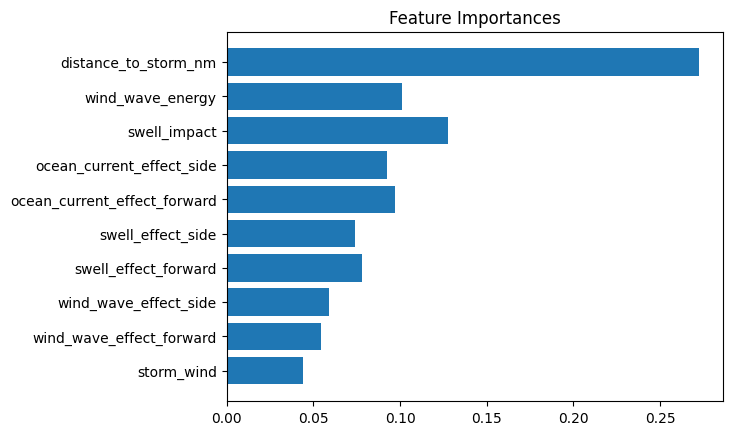

In [ ]:
best_model = joblib.load("best_model.pkl")
importances = best_model.feature_importances_
features = X_train.columns
plt.barh(features, importances)
plt.title("Feature Importances")

# Export feature importances as png
plt.savefig("feature_importances.png", bbox_inches='tight')

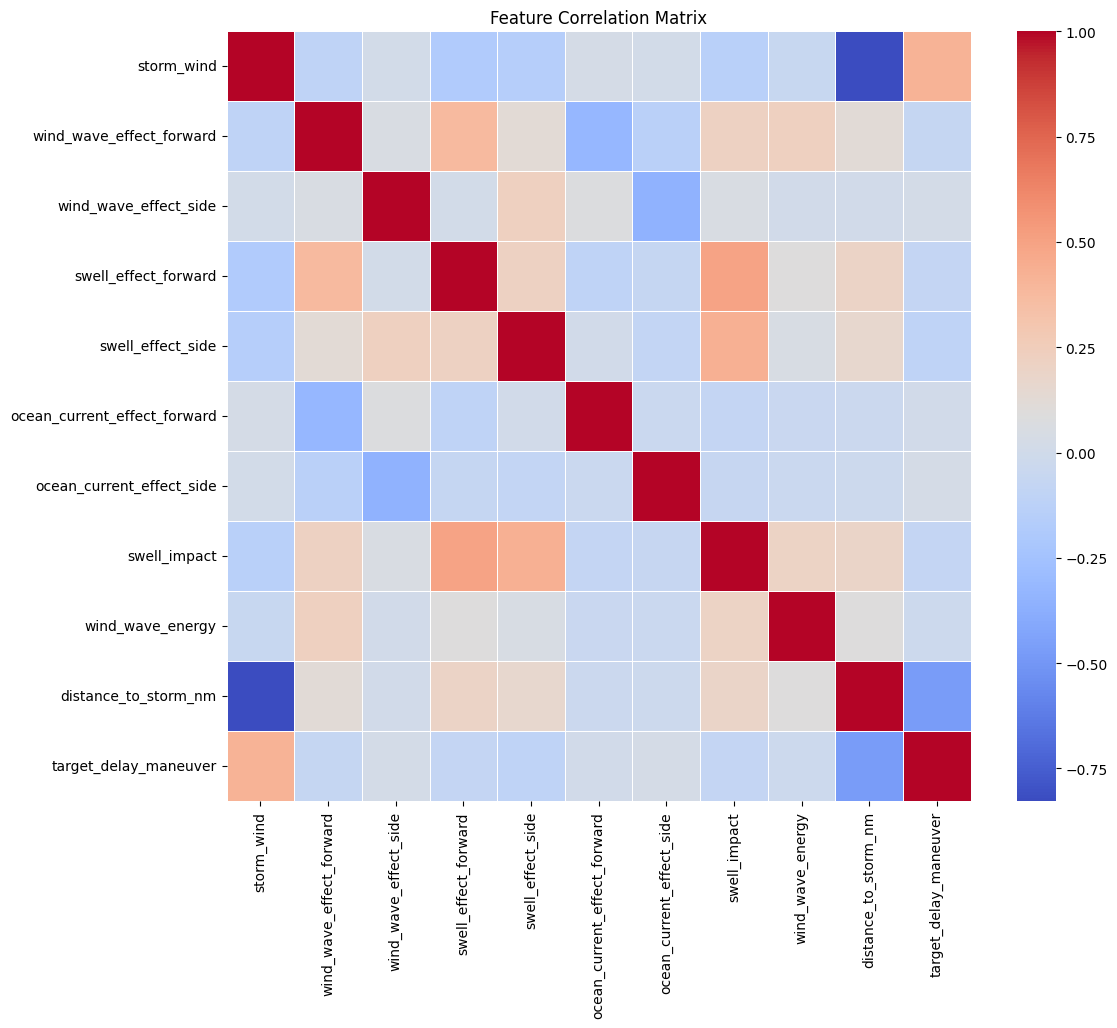

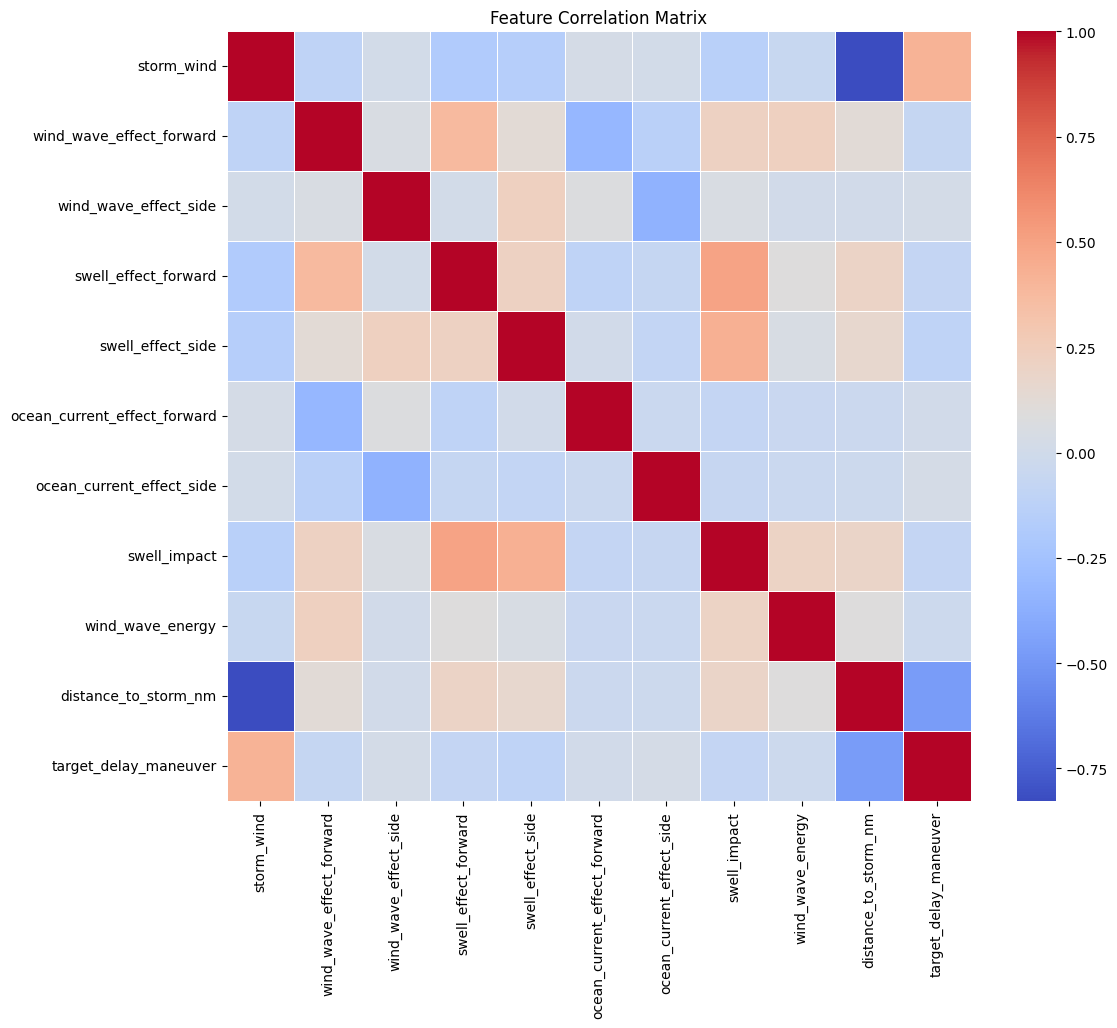

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = train_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Save heatmap as PNG
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.savefig("feature_correlation_matrix.png", bbox_inches='tight')